In [1]:
from pathlib import Path

from config import PLOTS_DIR
from core.sharpe_avar_sensitivity import (
    run_analysis, 
    AVarSensitivityFramework, StandardConstraints
)

In [2]:
def _example_garch() -> AVarSensitivityFramework:
    def avar(sr, alpha=0.08, beta=0.87, skew=0.0, exc_kurt=0.0, **kw):
        t1 = skew * (1 - beta) / (1 - alpha - beta)
        t2 = ((exc_kurt + 2) * (1 - beta) ** 2 * (1 + alpha + beta)
              / ((1 - alpha - beta) * (1 - 2 * alpha * beta - beta ** 2)))
        return 1 - sr * t1 + sr ** 2 / 4 * t2

    constraints = [
        StandardConstraints.garch_stationarity(),
        StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("sr"),
        #StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, constraints=constraints, name="GARCH11")

def _example_ar1_garch11_symm():
    def avar(sr, phi=0.2, alpha=0.08, beta=0.87, exc_kurt=3.0, **kw):
        k_r = exc_kurt + 3
        phi2 = phi ** 2
        den_com = 1 - 2 * alpha * beta - beta ** 2
        K = (1 + phi2) * k_r - 5 * phi2 - 1
        num_A = 1 - alpha * beta - beta ** 2
        factor_A = 1 - phi2 * (alpha + beta)
        A = 6 * phi2 * alpha * (num_A / den_com) * (1 / factor_A)
        params_ratio = ((1 - beta) ** 2 * (1 + alpha + beta)) / ((1 - alpha - beta) * den_com)
        S_vv = (1 / (1 - phi2)) * (4 * phi2 + (K / (1 + A)) * ((2 / 3) * A + params_ratio))
        return (1 + phi) / (1 - phi) + 0.25 * sr ** 2 * S_vv

    # Don't pass parameters — let the sniffer demonstrate auto-introspection.
    constraints = [
        StandardConstraints.garch_stationarity(),
        #StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.garch_fourth_moment(),
        StandardConstraints.ar_stationarity("phi"),
        #StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("exc_kurt"),
        StandardConstraints.positive("sr"),
        #StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, constraints=constraints, name="AR1-GARCH11-symm")

def _example_ar1_garch11():
    def avar(sr, phi=0.2, alpha=0.08, beta=0.87, exc_kurt=5.0, skew=0, **kw):
        k_r = exc_kurt + 3.0

        # ---- shorthand ----
        p    = alpha + beta
        phi2   = phi * phi
        om_p2  = 1.0 - phi2                          # 1 - phi^2
        om_r   = 1.0 - p                           # 1 - alpha - beta
        den_z  = 1.0 - 2.0*alpha*beta - beta*beta    
        g      = 1.0 + 2.0*phi*alpha - phi*beta  

        # =====================  S_11 / sigma^2  =====================
        S11n = (1.0 + phi) / (1.0 - phi)

        # =====================  S_12 / sigma^3  =====================
        bracket12 = 2.0*phi*alpha + (1.0 - beta) * (1.0 - phi*p) / om_r
        S12n = skew * (1.0 + phi + phi2) / (om_p2 * g) * bracket12

        # =====================  S_22 / sigma^4  =====================
        # M_1 / sigma^4 = m1 * skew^2   (Taylor expansion of sigma_t^3 around sigma_u^3)
        m1 = (3.0 * alpha * (1.0 - phi) * (1.0 + phi + phi2)**2 * (1.0 - phi*p)) \
            / (2.0 * (1.0 + phi) * g**2)
        M1 = m1 * skew**2

        P = alpha * (1.0 - alpha*beta - beta*beta) / den_z
        Q = 1.0 - phi2 * p

        K = (Q * (1.0 - phi2) * ((1.0 + phi2)*k_r -1-5*phi2)-4*phi*M1*(1+phi2*(2*alpha-beta))) / (Q+6*phi2*P)

        H1 = (2*phi*alpha*M1 + K*P)/Q + 1-phi2

        A = 2*phi/ (1-phi2)
        B = (1-beta)/((1-phi2)*(1-p))

        R= (1-p**2)/(1-2*alpha*beta-beta**2)

        S22n = A**2*H1 + B**2*K*R + 2*A*B*M1

        return S11n - sr * S12n + 0.25 * sr * sr * S22n

    # Don't pass parameters — let the sniffer demonstrate auto-introspection.
    constraints = [
        StandardConstraints.garch_stationarity(),
        #StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.garch_fourth_moment(),
        StandardConstraints.ar_stationarity("phi"),
        StandardConstraints.lower_bound("exc_kurt", 3),
        StandardConstraints.positive("exc_kurt"),
        StandardConstraints.positive("sr"),
        #StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, constraints=constraints, name="AR1-GARCH11")




Model: AR1-GARCH11
Parameters: ['sr', 'phi', 'alpha', 'beta', 'exc_kurt', 'skew']
Base point: {'sr': 0.5, 'phi': 0.2, 'alpha': 0.08, 'beta': 0.87, 'exc_kurt': 5.0, 'skew': 0.0}
Base AVar: 4.3661
Constraints:
  - alpha + beta < 1
  - kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1
  - |phi| < 1
  - exc_kurt > 3
  - exc_kurt > 0
  - sr > 0

1. OAT SWEEPS (feasible only)
  sr            n= 200   AVar in [1.615, 47.357]
  phi           n= 200   AVar in [3.518, 26.748]
  alpha         n=  47   AVar in [1.975, 25.122]
  beta          n= 186   AVar in [2.050, 32.785]
  exc_kurt      n= 170   AVar in [3.538, 10.623]
  skew          n= 200   AVar in [0.177, 8.223]

2. STRATIFIED MC (n=4000 per axis, feasible only)


C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\src\core\sharpe_avar_sensitivity.py:266: UserWarning: axis=exc_kurt: only 3393/4000 x-values found a feasible companion within 200 attempts each.
  warnings.warn(


             n  spearman     q05      q50       q95
axis                                               
sr        4000    0.7421  1.0759  12.3511   92.7403
phi       4000    0.0463  1.0945  12.0747   91.6586
alpha     4000    0.1951  1.1864  14.1628   89.0693
beta      4000    0.1447  1.0909  13.3190  111.0109
exc_kurt  3393    0.2533  1.0632  12.6198   90.0725
skew      4000   -0.2162  1.0599  12.4718   94.1460


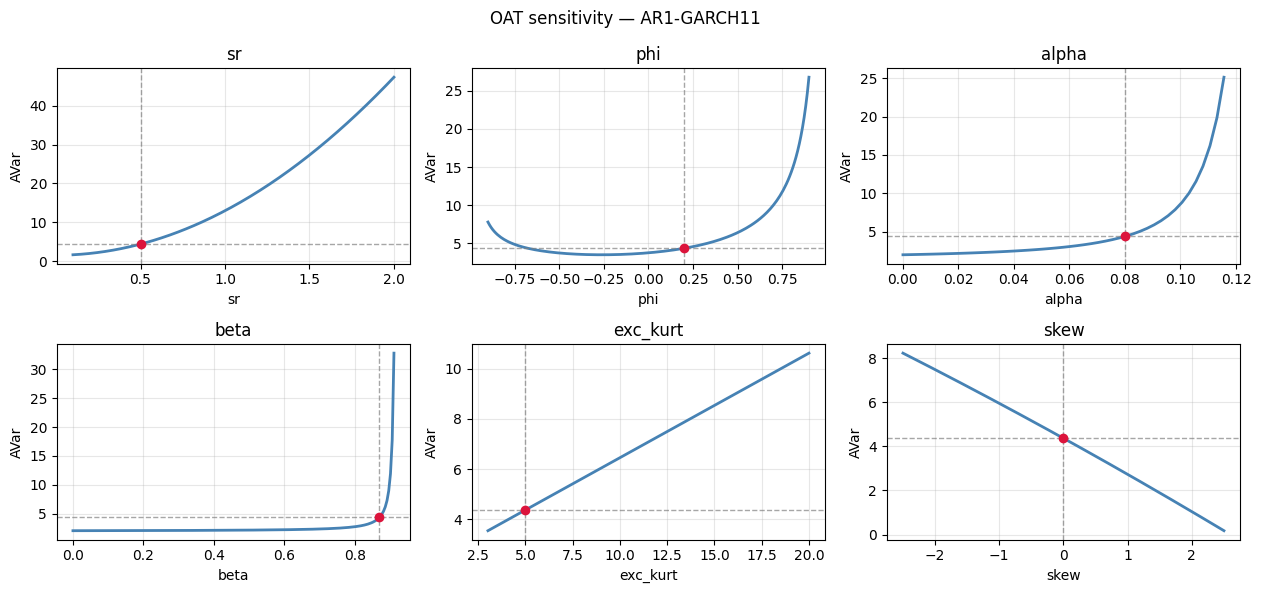

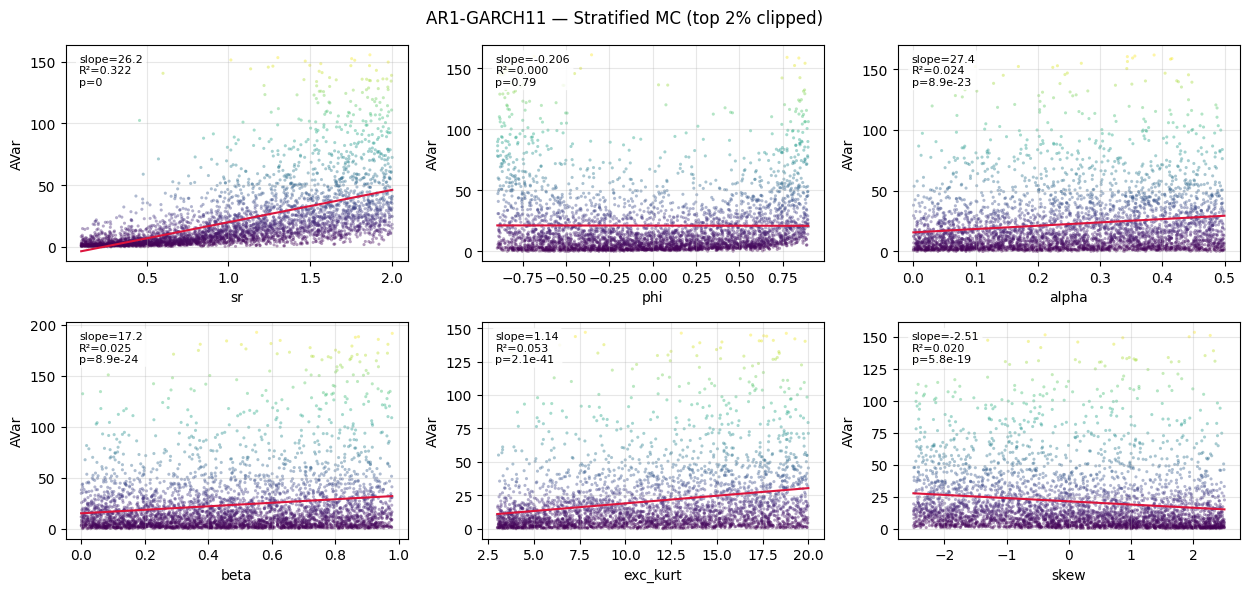

In [3]:
run_analysis(_example_ar1_garch11(), PLOTS_DIR / "ar1_garch11")

Model: AR1-GARCH11-symm
Parameters: ['sr', 'phi', 'alpha', 'beta', 'exc_kurt']
Base point: {'sr': 0.5, 'phi': 0.2, 'alpha': 0.08, 'beta': 0.87, 'exc_kurt': 3.0}
Base AVar: 3.5318
Constraints:
  - alpha + beta < 1
  - kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1
  - |phi| < 1
  - exc_kurt > 0
  - sr > 0

1. OAT SWEEPS (feasible only)
  sr            n= 199   AVar in [1.501, 34.009]
  phi           n= 200   AVar in [2.623, 24.183]
  alpha         n=  47   AVar in [1.839, 18.225]
  beta          n= 186   AVar in [1.892, 23.649]
  exc_kurt      n= 199   AVar in [2.322, 10.623]

2. STRATIFIED MC (n=4000 per axis, feasible only)
             n  spearman     q05      q50      q95
axis                                              
sr        4000    0.7609  0.8231   9.2829  61.7914
phi       4000    0.1966  0.7901  10.0783  67.4145
alpha     4000    0.1060  0.8245  10.1161  64.4867
beta      4000    0.1497  0.8869  10.8244  82.7154
exc_kurt  4000    0.3228  0.7688   9.2562  64.9612


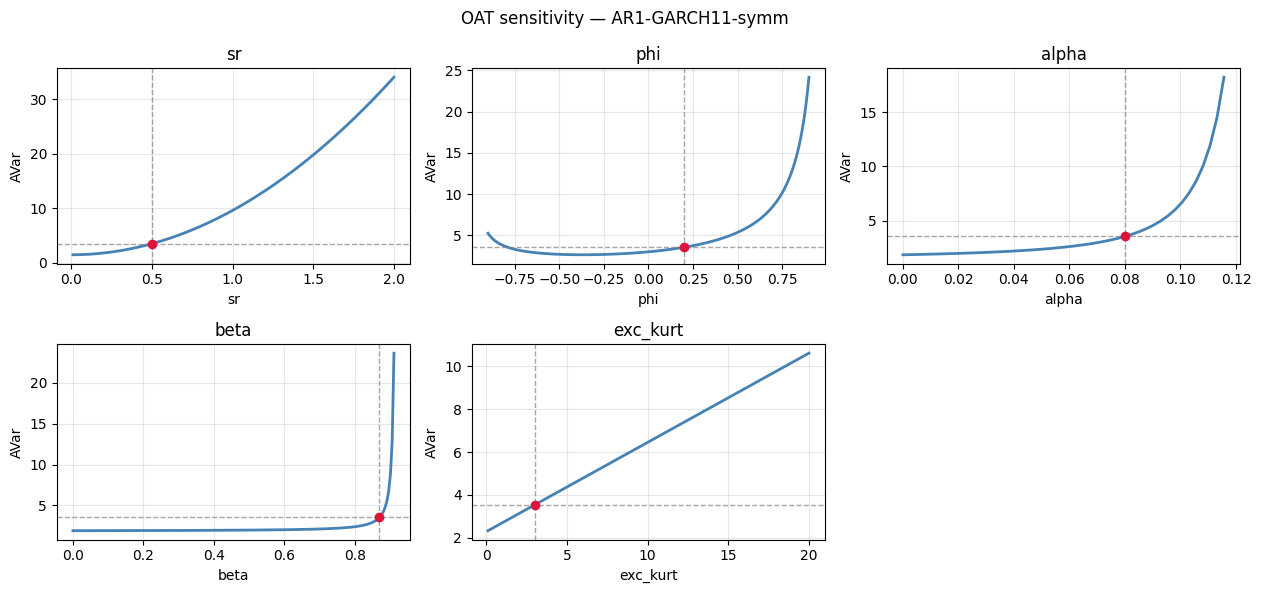

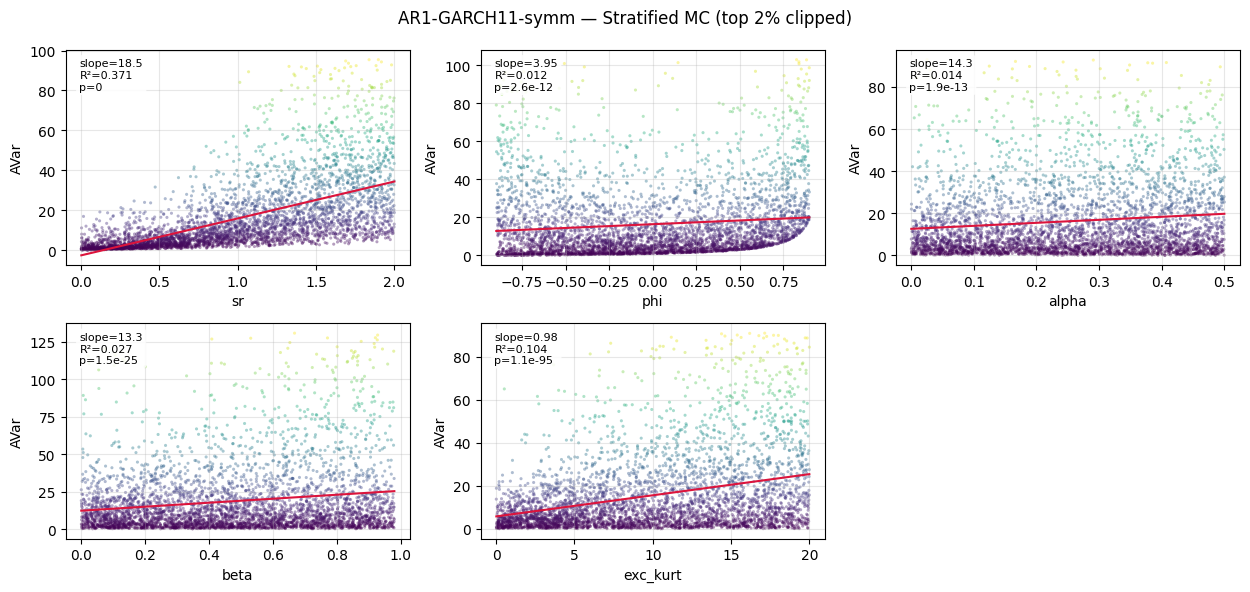

In [6]:
run_analysis(_example_ar1_garch11_symm(), PLOTS_DIR / "ar1_garch11_symm")

Model: GARCH11
Parameters: ['sr', 'alpha', 'beta', 'skew', 'exc_kurt']
Base point: {'sr': 0.5, 'alpha': 0.08, 'beta': 0.87, 'skew': 0.0, 'exc_kurt': 0.0}
Base AVar: 1.7929
Constraints:
  - alpha + beta < 1
  - kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1
  - exc_kurt > 0
  - sr > 0

1. OAT SWEEPS (feasible only)
  sr            no feasible points
  alpha         no feasible points
  beta          no feasible points
  skew          no feasible points
  exc_kurt      n= 131   AVar in [1.833, 7.013]

2. STRATIFIED MC (n=4000 per axis, feasible only)


C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\src\core\sharpe_avar_sensitivity.py:262: UserWarning: axis=alpha: only 3941/4000 x-values found a feasible companion within 200 attempts each.
  warnings.warn(


             n  spearman     q05     q50      q95
axis                                             
sr        4000    0.7478  0.3441  4.1696  21.8928
alpha     3941   -0.1688 -0.4929  3.7061  19.8505
beta      4000    0.1263  0.4586  4.3629  25.5853
skew      4000   -0.3970  0.4242  4.5019  22.5296
exc_kurt  4000    0.3213  0.4700  4.6557  23.3548


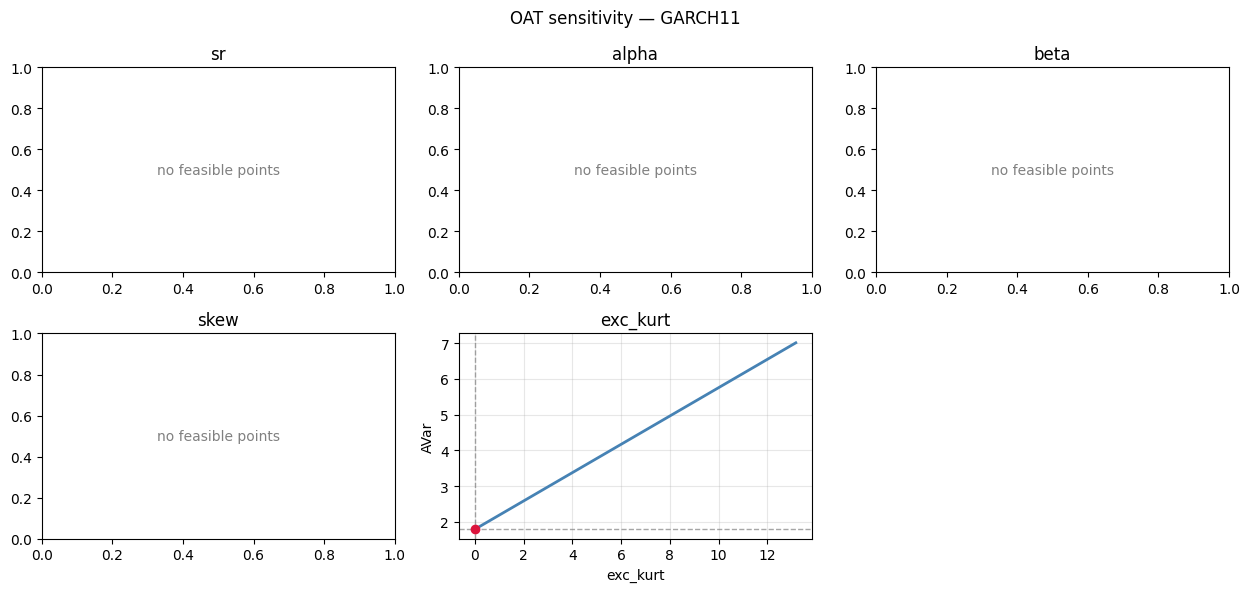

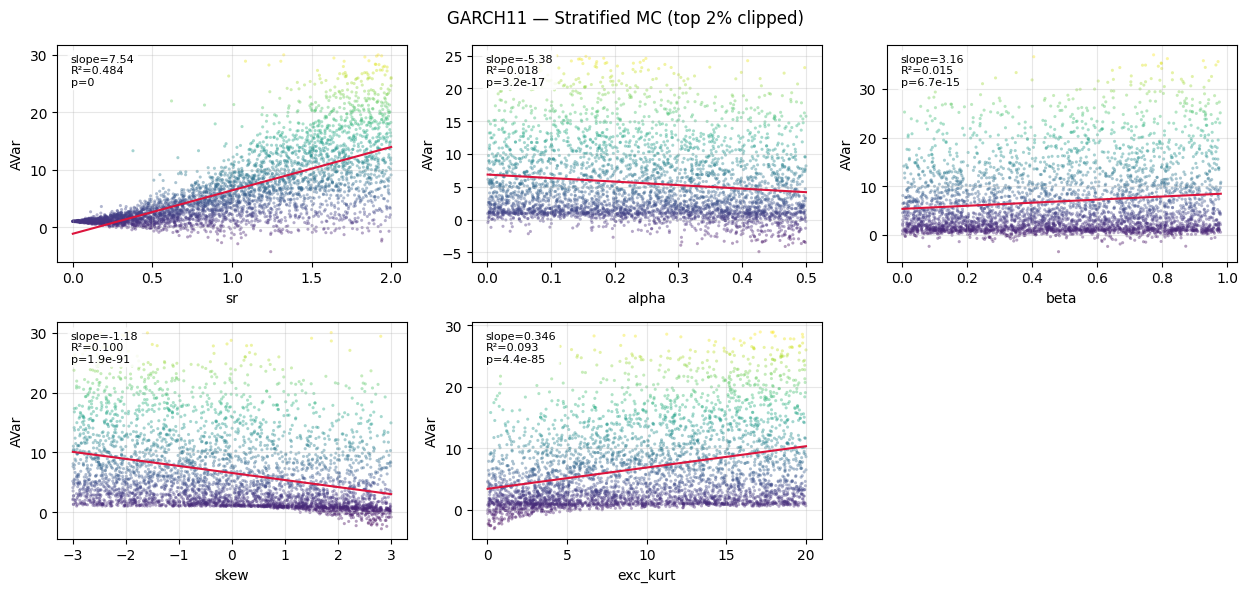

In [4]:
run_analysis(_example_garch(), PLOTS_DIR / "garch11")